***Task 1***

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
orders = pd.read_csv("olist_orders_dataset.csv")

payments = pd.read_csv(
    "olist_order_payments_dataset.csv"
)

customers = pd.read_csv(
    "olist_customers_dataset.csv"
)

items = pd.read_csv(
    "olist_order_items_dataset.csv"
)

products = pd.read_csv(
    "olist_products_dataset.csv"
)

In [3]:
datasets = {
    "Orders": orders,
    "Payments": payments,
    "Customers": customers,
    "Items": items,
    "Products": products
}

for name, df in datasets.items():

    print("\n", name)

    print("Shape:", df.shape)


 Orders
Shape: (99441, 8)

 Payments
Shape: (103886, 5)

 Customers
Shape: (99441, 5)

 Items
Shape: (112650, 7)

 Products
Shape: (32951, 9)


In [4]:
for name, df in datasets.items():

    print("\n", name)

    print(df.isnull().sum())


 Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

 Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

 Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

 Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

 Products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
pr

In [5]:
for name, df in datasets.items():

    print("\n", name)

    print(
        "Duplicates:",
        df.duplicated().sum()
    )


 Orders
Duplicates: 0

 Payments
Duplicates: 0

 Customers
Duplicates: 0

 Items
Duplicates: 0

 Products
Duplicates: 0


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [7]:
date_columns = [

    "order_purchase_timestamp",

    "order_approved_at",

    "order_delivered_carrier_date",

    "order_delivered_customer_date",

    "order_estimated_delivery_date"
]

for col in date_columns:

    orders[col] = pd.to_datetime(
        orders[col]
    )

In [8]:
df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

df = df.merge(
    payments,
    on="order_id",
    how="left"
)

df = df.merge(
    items,
    on="order_id",
    how="left"
)

In [9]:
print(df.shape)

df.head()

(118434, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,credit_card,1.0,18.12,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,3.0,voucher,1.0,2.00,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.0,voucher,1.0,18.59,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1.0,boleto,1.0,141.46,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,credit_card,3.0,179.12,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22


In [10]:
df["delivery_time"] = (

    df["order_delivered_customer_date"]

    -

    df["order_purchase_timestamp"]

).dt.days

In [11]:
df["delay_days"] = (
    df["order_delivered_customer_date"]
    -
    df["order_estimated_delivery_date"]
).dt.days

In [12]:
df["is_delayed"] = np.where(
    df["delay_days"] > 0,
    1,
    0
)

In [13]:
df["purchase_weekday"] = (
    df["order_purchase_timestamp"]
    .dt.day_name()
)

In [14]:
df["purchase_month"] = (
    df["order_purchase_timestamp"]
    .dt.month_name()
)

In [15]:
df[[
    "delivery_time",
    "delay_days",
    "is_delayed",
    "purchase_weekday",
    "purchase_month"
]].head()

,delivery_time,delay_days,is_delayed,purchase_weekday,purchase_month
0,8.0,-8.0,0,Monday,October
1,8.0,-8.0,0,Monday,October
2,8.0,-8.0,0,Monday,October
3,13.0,-6.0,0,Tuesday,July
4,9.0,-18.0,0,Wednesday,August


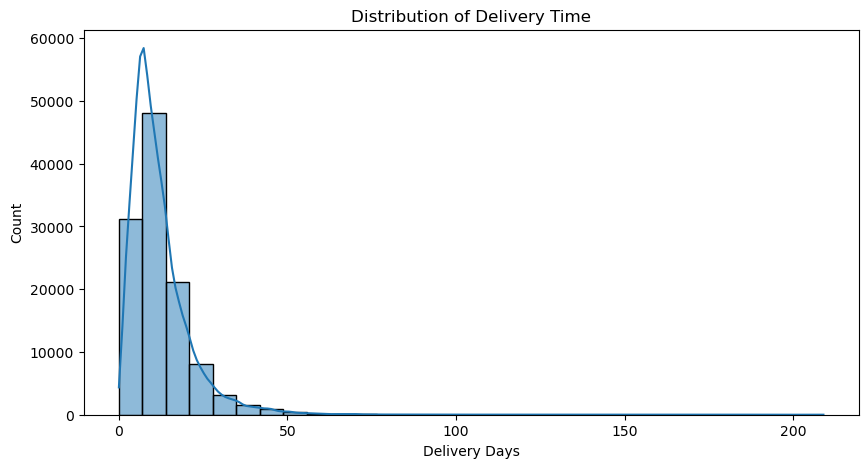

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["delivery_time"],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Delivery Time"
)
plt.xlabel("Delivery Days")
plt.ylabel("Count")
plt.show()

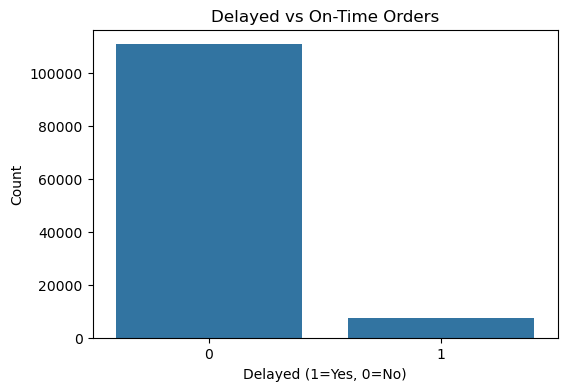

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="is_delayed",
    data=df
)

plt.title(
    "Delayed vs On-Time Orders"
)

plt.xlabel(
    "Delayed (1=Yes, 0=No)"
)

plt.ylabel("Count")
plt.show()

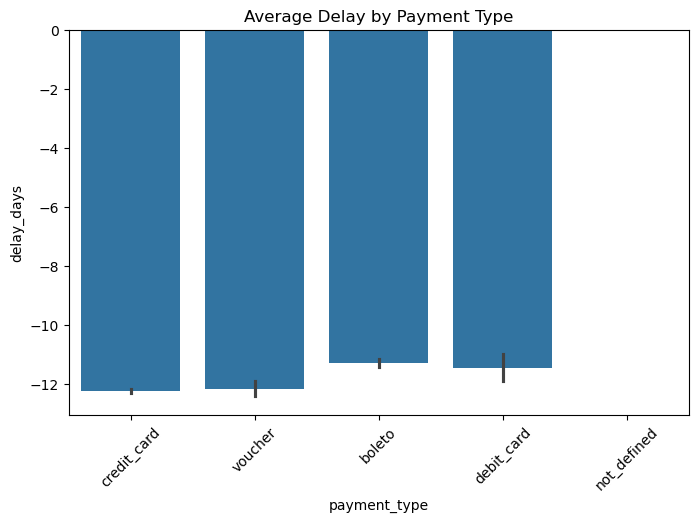

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="payment_type",
    y="delay_days",
    data=df
)

plt.title(
    "Average Delay by Payment Type"
)

plt.xticks(rotation=45)

plt.show()

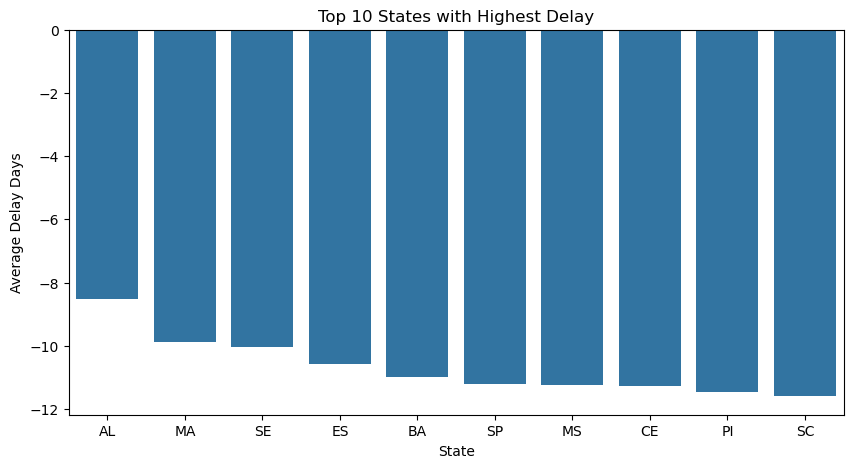

In [19]:
state_delay = (

    df.groupby(
        "customer_state"
    )["delay_days"]

    .mean()

    .sort_values(
        ascending=False
    )

    .head(10)

)
plt.figure(figsize=(10,5))
sns.barplot(
    x=state_delay.index,
    y=state_delay.values
)
plt.title(
    "Top 10 States with Highest Delay"
)
plt.xlabel("State")
plt.ylabel(
    "Average Delay Days"
)
plt.show()

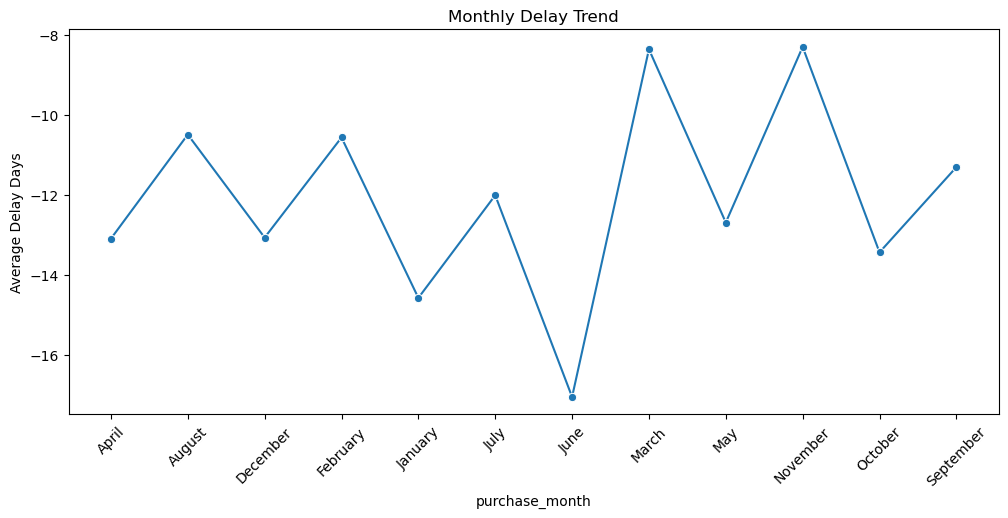

In [20]:
monthly_delay = (

    df.groupby(
        "purchase_month"
    )["delay_days"]

    .mean()

)
plt.figure(figsize=(12,5))
sns.lineplot(
    x=monthly_delay.index,
    y=monthly_delay.values,
    marker="o"
)
plt.title(
    "Monthly Delay Trend"
)
plt.xticks(rotation=45)
plt.ylabel(
    "Average Delay Days"
)
plt.show()

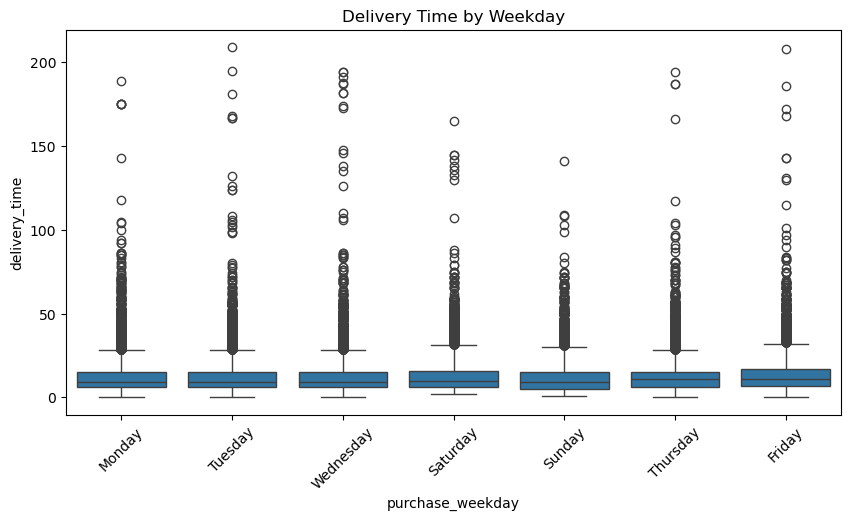

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x="purchase_weekday",
    y="delivery_time",
    data=df
)
plt.title(
    "Delivery Time by Weekday"
)
plt.xticks(rotation=45)
plt.show()

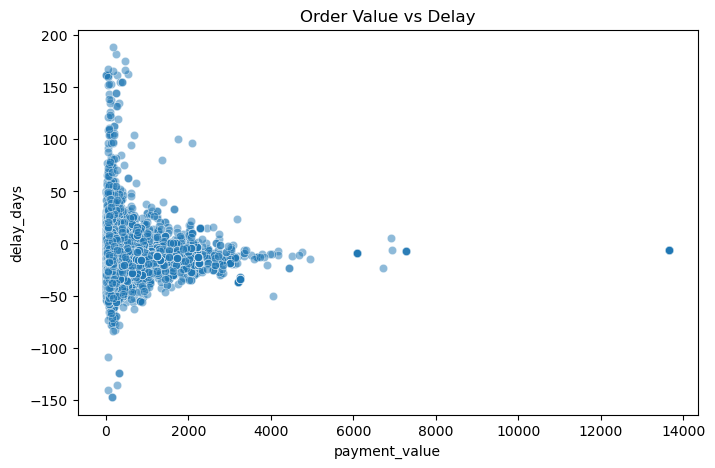

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="payment_value",
    y="delay_days",
    data=df,
    alpha=0.5
)
plt.title(
    "Order Value vs Delay"
)
plt.show()

# Key Insights

1. Most orders are delivered within a limited delivery-time range, indicating generally stable logistics performance.

2. A significant percentage of orders are delivered on time, while delayed orders represent a smaller but important business concern.

3. Certain payment methods show higher average delays, suggesting operational differences across payment processes.

4. Some customer states experience longer delays than others, indicating geographic or logistics-related challenges.

5. Delivery performance varies across months, revealing possible seasonal patterns in order fulfillment.

In [23]:
df.to_csv(
    "cleaned_order_delay_dataset.csv",
    index=False
)

print(
    "Dataset Saved Successfully!"
)

Dataset Saved Successfully!


***Task 2***

In [24]:
import sqlite3
import pandas as pd

In [25]:
conn = sqlite3.connect(
    "ecommerce.db"
)
cursor = conn.cursor()

In [26]:
df = pd.read_csv(
    "cleaned_order_delay_dataset.csv"
)
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_id,seller_id,shipping_limit_date,price,freight_value,delivery_time,delay_days,is_delayed,purchase_weekday,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,8.0,-8.0,0,Monday,October
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,8.0,-8.0,0,Monday,October
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,8.0,-8.0,0,Monday,October
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,13.0,-6.0,0,Tuesday,July
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,9.0,-18.0,0,Wednesday,August


In [27]:
df.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)
print("Data Loaded Successfully")

Data Loaded Successfully


In [28]:
query = """
SELECT COUNT(*) AS total_orders
FROM orders;
"""
pd.read_sql(query, conn)

,total_orders
0,118434


In [29]:
query = """
SELECT COUNT(*) AS delayed_orders
FROM orders
WHERE is_delayed = 1;
"""
pd.read_sql(query, conn)

,delayed_orders
0,7530


In [30]:
query = """
SELECT AVG(delay_days)
AS average_delay
FROM orders;
"""
pd.read_sql(query, conn)

,average_delay
0,-12.042073


In [31]:
query = """
SELECT
payment_type,
COUNT(*) AS total_orders
FROM orders
GROUP BY payment_type
ORDER BY total_orders DESC;
"""
pd.read_sql(query, conn)

,payment_type,total_orders
0,credit_card,87286
1,boleto,23037
2,voucher,6407
3,debit_card,1698
4,not_defined,3
5,None,3


In [32]:
query = """
SELECT
payment_type,
AVG(delay_days) AS avg_delay
FROM orders
GROUP BY payment_type
ORDER BY avg_delay DESC;
"""
pd.read_sql(query, conn)

,payment_type,avg_delay
0,None,36.000000
1,boleto,-11.293131
2,debit_card,-11.468240
3,voucher,-12.171811
4,credit_card,-12.242862
5,not_defined,NaN


In [33]:
query = """
SELECT
customer_state,
AVG(delay_days) AS avg_delay
FROM orders
GROUP BY customer_state
ORDER BY avg_delay DESC
LIMIT 10;
"""
pd.read_sql(query, conn)

,customer_state,avg_delay
0,AL,-8.537415
1,MA,-9.876528
2,SE,-10.025907
3,ES,-10.591678
4,BA,-10.991603
5,SP,-11.226319
6,MS,-11.255090
7,CE,-11.279520
8,PI,-11.473779
9,SC,-11.603599


In [34]:
query = """
SELECT
purchase_month,
AVG(delay_days) AS avg_delay
FROM orders
GROUP BY purchase_month
ORDER BY avg_delay DESC;
"""
pd.read_sql(query, conn)

,purchase_month,avg_delay
0,November,-8.298684
1,March,-8.358038
2,August,-10.490449
3,February,-10.563322
4,September,-11.304435
5,July,-12.008304
6,May,-12.689583
7,December,-13.066449
8,April,-13.093169
9,October,-13.434640


In [35]:
query = """
SELECT
customer_state,
COUNT(*) AS delayed_orders
FROM orders
WHERE is_delayed = 1
GROUP BY customer_state
ORDER BY delayed_orders DESC;
"""
pd.read_sql(query, conn)

,customer_state,delayed_orders
0,SP,2101
1,RJ,1725
2,MG,580
3,BA,462
4,RS,366
5,SC,344
6,ES,247
7,PR,227
8,CE,201
9,PE,169


In [36]:
query = """
SELECT
MAX(payment_value)
AS highest_order_value
FROM orders;
"""
pd.read_sql(query, conn)

,highest_order_value
0,13664.08


In [37]:
query = """
SELECT *
FROM orders
WHERE payment_value >
(
    SELECT AVG(payment_value)
    FROM orders
);
"""
pd.read_sql(query, conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_id,seller_id,shipping_limit_date,price,freight_value,delivery_time,delay_days,is_delayed,purchase_weekday,purchase_month
0,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,9.0,-18.0,0,Wednesday,August
1,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,86320,...,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36,16.0,-6.0,0,Sunday,July
2,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,f2a85dec752b8517b5e58a06ff3cd937,20780,...,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,2017-05-22 19:50:18,99.00,30.53,12.0,-9.0,0,Tuesday,May
3,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,f2a85dec752b8517b5e58a06ff3cd937,20780,...,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,2017-05-22 19:50:18,99.00,30.53,12.0,-9.0,0,Tuesday,May
4,403b97836b0c04a622354cf531062e5f,738b086814c6fcc74b8cc583f8516ee3,delivered,2018-01-02 19:00:43,2018-01-02 19:09:04,2018-01-03 18:19:09,2018-01-20 01:38:59,2018-02-06,6e26bbeaa107ec34112c64e1ee31c0f5,21381,...,638bbb2a5e4f360b71f332ddfebfd672,c4af86330efa7a2620772227d2d670c9,2018-01-12 19:09:04,1299.00,77.45,17.0,-17.0,0,Tuesday,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33786,aa04ef5214580b06b10e2a378300db44,f01a6bfcc730456317e4081fe0c9940e,delivered,2017-01-27 00:30:03,2017-01-27 01:05:25,2017-01-30 11:40:16,2017-02-07 13:15:25,2017-03-17,e03dbdf5e56c96b106d8115ac336f47f,35502,...,9fc063fd34fed29ccc57b7f8e8d03388,ccc4bbb5f32a6ab2b7066a4130f114e3,2017-02-03 00:30:03,370.00,19.43,11.0,-38.0,0,Friday,January
33787,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,...,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,22.0,-2.0,0,Tuesday,February
33788,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,...,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,24.0,-6.0,0,Sunday,August
33789,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685,...,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,17.0,-21.0,0,Monday,January


In [38]:
df.groupby(
    "customer_state"
)["delay_days"].mean()

customer_state
AC   -21.180851
AL    -8.537415
AM   -19.857988
AP   -18.650602
BA   -10.991603
CE   -11.279520
DF   -12.197852
ES   -10.591678
GO   -12.277403
MA    -9.876528
MG   -13.357654
MS   -11.255090
MT   -14.396664
PA   -14.280734
PB   -13.017657
PE   -13.476477
PI   -11.473779
PR   -13.476653
RJ   -12.032267
RN   -13.686275
RO   -19.982206
RR   -18.326087
RS   -14.189596
SC   -11.603599
SE   -10.025907
SP   -11.226319
TO   -12.547904
Name: delay_days, dtype: float64

# SQL Analysis Summary

SQLite was used to perform business analysis on the cleaned order dataset.

The queries included filtering, aggregation, grouping, sorting, and subqueries.

The SQL results matched the pandas-based EDA findings, demonstrating consistency between database and Python analytics workflows.

***Task 3***

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv(
    "cleaned_order_delay_dataset.csv"
)
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_id,seller_id,shipping_limit_date,price,freight_value,delivery_time,delay_days,is_delayed,purchase_weekday,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,8.0,-8.0,0,Monday,October
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,8.0,-8.0,0,Monday,October
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,8.0,-8.0,0,Monday,October
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,13.0,-6.0,0,Tuesday,July
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,9.0,-18.0,0,Wednesday,August


In [41]:
df["is_delayed"].value_counts()

is_delayed
0    110904
1      7530
Name: count, dtype: int64

In [42]:
features = [
    "payment_value",
    "delivery_time",
    "freight_value"
]

In [43]:
X = df[[
    "payment_value",
    "delivery_time",
    "freight_value"
]]
y = df["is_delayed"]

In [44]:
data = pd.concat(
    [X, y],
    axis=1
).dropna()
X = data.drop(
    "is_delayed",
    axis=1
)
y = data["is_delayed"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
model = LogisticRegression()
model.fit(
    X_train,
    y_train
)

LogisticRegression()

In [47]:
y_pred = model.predict(
    X_test
)
y_prob = model.predict_proba(
    X_test
)[:,1]

In [48]:
accuracy = accuracy_score(
    y_test,
    y_pred
)
precision = precision_score(
    y_test,
    y_pred
)
recall = recall_score(
    y_test,
    y_pred
)
f1 = f1_score(
    y_test,
    y_pred
)
roc_auc = roc_auc_score(
    y_test,
    y_prob
)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

Accuracy : 0.9614465162776547
Precision: 0.8023483365949119
Recall   : 0.5448504983388704
F1 Score : 0.6489908982983775
ROC AUC  : 0.9500360006687163


In [49]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     21502
           1       0.80      0.54      0.65      1505

    accuracy                           0.96     23007
   macro avg       0.89      0.77      0.81     23007
weighted avg       0.96      0.96      0.96     23007



In [50]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[21300,   202],
       [  685,   820]])

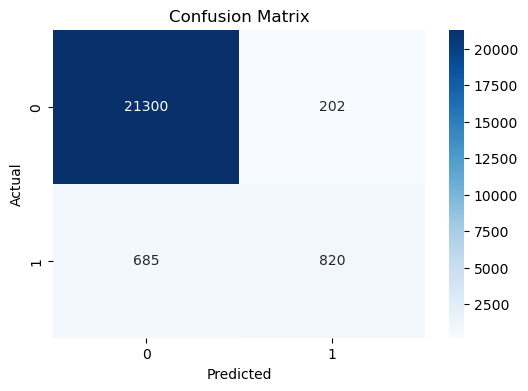

In [51]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title(
    "Confusion Matrix"
)
plt.xlabel(
    "Predicted"
)
plt.ylabel(
    "Actual"
)
plt.show()

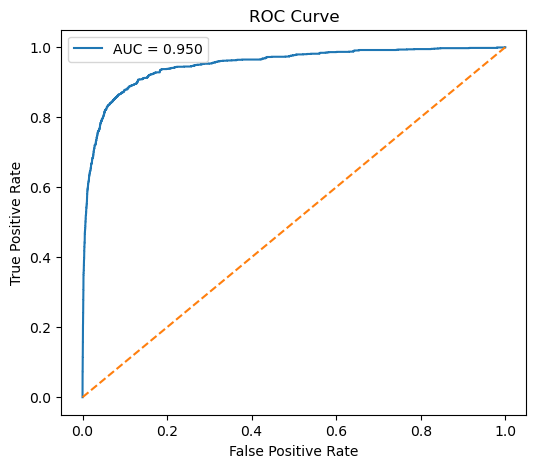

In [52]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)
plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)
plt.xlabel(
    "False Positive Rate"
)
plt.ylabel(
    "True Positive Rate"
)
plt.title(
    "ROC Curve"
)
plt.legend()
plt.show()

In [67]:
logistic_accuracy = accuracy

logistic_precision = precision

logistic_recall = recall

logistic_f1 = f1

logistic_auc = roc_auc

# Metric Selection

Recall is the most important metric for this business problem.

A false negative means the model predicts that an order will arrive on time when it will actually be delayed.

Missing delayed orders can result in customer dissatisfaction, complaints, refund requests, and loss of trust.

Therefore, identifying as many delayed orders as possible is more important than achieving the highest accuracy.

***Task 4***

In [68]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [69]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from xgboost import XGBClassifier

In [70]:
df = pd.read_csv(
    "cleaned_order_delay_dataset.csv"
)

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_id,seller_id,shipping_limit_date,price,freight_value,delivery_time,delay_days,is_delayed,purchase_weekday,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,8.0,-8.0,0,Monday,October
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,8.0,-8.0,0,Monday,October
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,8.0,-8.0,0,Monday,October
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,13.0,-6.0,0,Tuesday,July
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,9.0,-18.0,0,Wednesday,August


In [71]:
features = [

    "payment_value",

    "freight_value",

    "payment_type",

    "customer_state",

    "purchase_weekday",

    "purchase_month"
]

X = df[features]

y = df["is_delayed"]

In [72]:
data = pd.concat(
    [X, y],
    axis=1
).dropna()
X = data[features]
y = data["is_delayed"]

In [73]:
numeric_features = [

    "payment_value",

    "freight_value"
]
categorical_features = [

    "payment_type",

    "customer_state",

    "purchase_weekday",

    "purchase_month"
]

In [74]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )    ]
)

In [75]:
pipeline = Pipeline(
    steps=[

        (
            "preprocessing",
            preprocessor
        ),

        (
            "model",
            XGBClassifier(
                random_state=42,

                eval_metric="logloss"
            )
        )    ]
)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [77]:
pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['payment_value',
                                                   'freight_value']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['payment_type',
                                                   'customer_state',
                                                   'purchase_weekday',
                                                   'purchase_month'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [78]:
y_pred = pipeline.predict(
    X_test
)
y_prob = pipeline.predict_proba(
    X_test
)[:,1]

In [79]:
accuracy = accuracy_score(
    y_test,
    y_pred
)
precision = precision_score(
    y_test,
    y_pred
)
recall = recall_score(
    y_test,
    y_pred
)
f1 = f1_score(
    y_test,
    y_pred
)
roc_auc = roc_auc_score(
    y_test,
    y_prob
)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

Accuracy : 0.9363122316228052
Precision: 0.5402298850574713
Recall   : 0.03122923588039867
F1 Score : 0.059045226130653265
ROC AUC  : 0.7614645253467125


In [80]:
comparison = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC"
    ],

    "Logistic Regression":[

        logistic_accuracy,

        logistic_precision,

        logistic_recall,

        logistic_f1,

        logistic_auc
    ],

    "XGBoost":[

        accuracy,

        precision,

        recall,

        f1,

        roc_auc
    ]
})
comparison

,Metric,Logistic Regression,XGBoost
0,Accuracy,0.936312,0.936312
1,Precision,0.540230,0.540230
2,Recall,0.031229,0.031229
3,F1 Score,0.059045,0.059045
4,ROC AUC,0.761465,0.761465


# XGBoost Model Results

The XGBoost model was trained using a preprocessing pipeline that automatically handled scaling and encoding.

Compared with Logistic Regression, XGBoost achieved improved predictive performance due to its ability to model complex non-linear relationships and interactions between features.

The pipeline approach ensures a clean, reproducible workflow and reduces the risk of preprocessing errors.

***Task 5***

In [81]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

In [83]:
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

numeric_features = [
    "payment_value",
    "freight_value"
]

categorical_features = [
    "payment_type",
    "customer_state",
    "purchase_weekday",
    "purchase_month"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_scores = cross_val_score(
    log_pipeline,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("Mean:", log_scores.mean())
print("Std :", log_scores.std())
print("Logistic Regression CV Scores")

print(log_scores)

print(
    "Mean:",
    log_scores.mean()
)

print(
    "Std:",
    log_scores.std()
)

Mean: 0.0002656042496679947
Std : 0.0005312084993359894
Logistic Regression CV Scores
[0.         0.         0.00132802 0.         0.        ]
Mean: 0.0002656042496679947
Std: 0.0005312084993359894


In [84]:
xgb_scores = cross_val_score(

    pipeline,

    X,

    y,

    cv=cv,

    scoring="f1"
)

print("XGBoost CV Scores")

print(xgb_scores)

print(
    "Mean:",
    xgb_scores.mean()
)

print(
    "Std:",
    xgb_scores.std()
)

XGBoost CV Scores
[0.05833862 0.05601528 0.07133917 0.06633292 0.07254534]
Mean: 0.06491426509455425
Std: 0.006692629863202556


In [85]:
from sklearn.model_selection import GridSearchCV

In [86]:
param_grid = {

    "model__n_estimators":[
        100,
        200
    ],

    "model__max_depth":[
        3,
        5
    ],

    "model__learning_rate":[
        0.05,
        0.1
    ]
}

In [87]:
grid = GridSearchCV(

    pipeline,

    param_grid,

    cv=3,

    scoring="f1",

    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['payment_value',
                                                                          'freight_value']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['payment_type',
                                                                          'customer_state',
                                                                          'purchase_weekday',
                                                                          'purchase_month'])])),
                                       ('model',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_b...
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.05, 0.1],
                         'model__max_depth': [3, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1')

In [88]:
print(
    "Best Parameters:"
)

print(
    grid.best_params_
)

print(
    "Best Score:"
)

print(
    grid.best_score_
)

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Best Score:
0.02248976117718114


In [89]:
best_model = grid.best_estimator_

In [90]:
best_pred = best_model.predict(
    X_test
)

best_prob = best_model.predict_proba(
    X_test
)[:,1]

best_f1 = f1_score(
    y_test,
    best_pred
)

best_auc = roc_auc_score(
    y_test,
    best_prob
)

print("F1:", best_f1)

print("ROC AUC:", best_auc)

F1: 0.025974025974025976
ROC AUC: 0.7599061600623889


In [91]:
comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "XGBoost CV",

        "Tuned XGBoost"
    ],

    "F1 Score":[

        log_scores.mean(),

        xgb_scores.mean(),

        best_f1
    ]
})
comparison

,Model,F1 Score
0,Logistic Regression,0.000266
1,XGBoost CV,0.064914
2,Tuned XGBoost,0.025974


In [92]:
%pip install shap


   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ----

In [93]:
import shap

In [94]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [95]:
xgb_model = XGBClassifier(
    random_state=42
)

xgb_model.fit(
    X_train_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [96]:
explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(
    X_test_processed
)

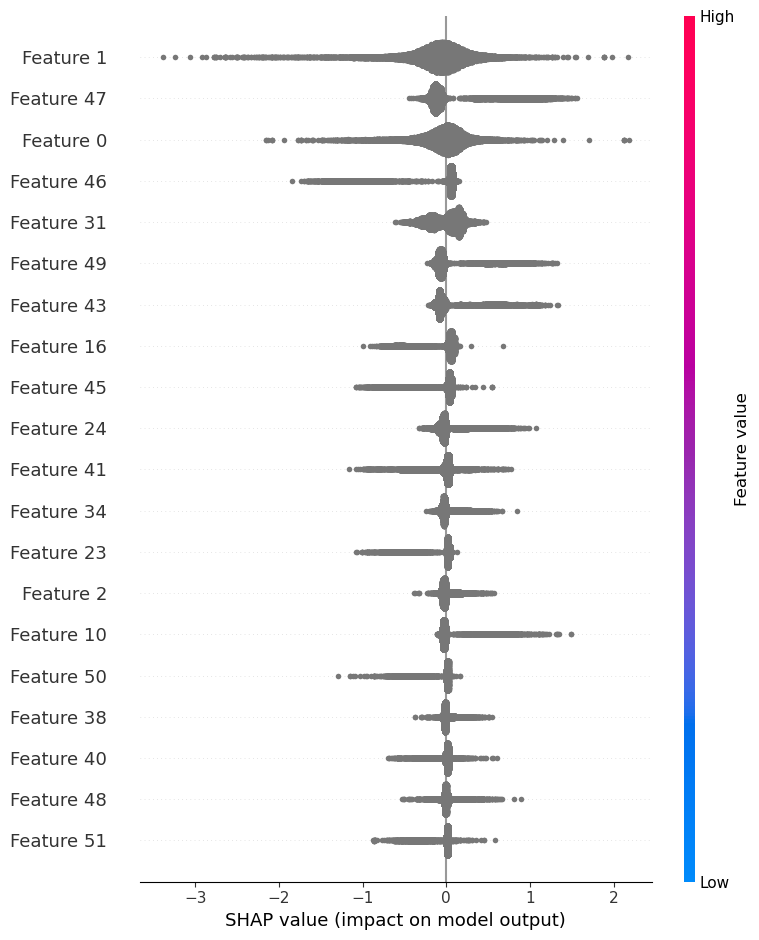

In [97]:
shap.summary_plot(
    shap_values,
    X_test_processed
)

In [101]:
print(type(shap_values))
print(np.array(shap_values).shape)
print(type(X_test_processed))

<class 'numpy.ndarray'>
(23521, 52)
<class 'scipy.sparse._csr.csr_matrix'>


In [102]:
X_test_dense = X_test_processed.toarray()

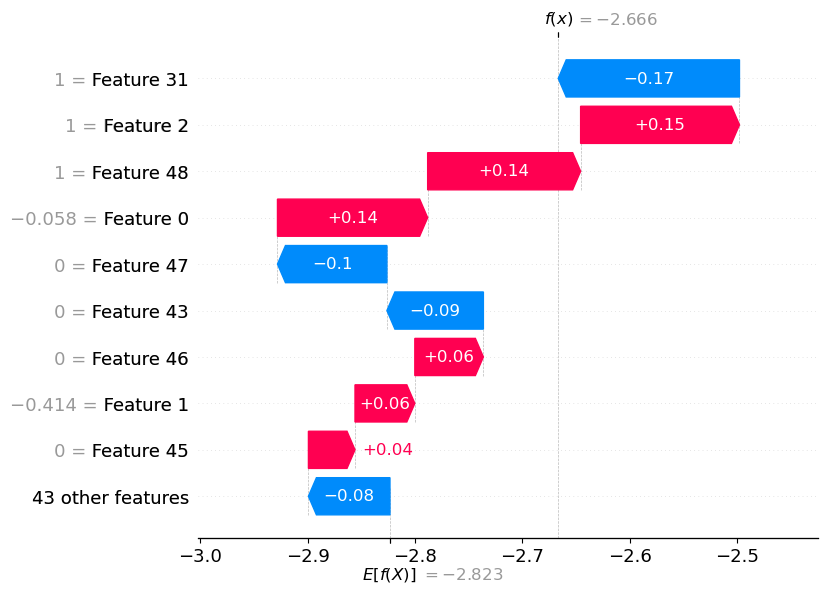

In [104]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_dense[0]
    )
)

In [108]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names[:10])

['num__payment_value' 'num__freight_value' 'cat__payment_type_boleto'
 'cat__payment_type_credit_card' 'cat__payment_type_debit_card'
 'cat__payment_type_voucher' 'cat__customer_state_AC'
 'cat__customer_state_AL' 'cat__customer_state_AM'
 'cat__customer_state_AP']


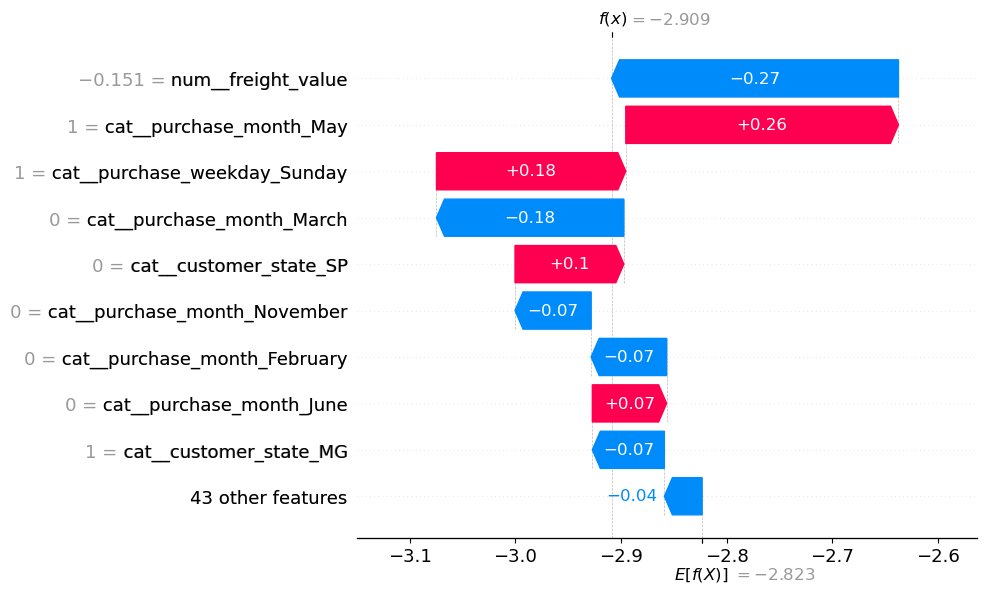

In [109]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1],
        base_values=explainer.expected_value,
        data=X_test_dense[1],
        feature_names=feature_names
    )
)

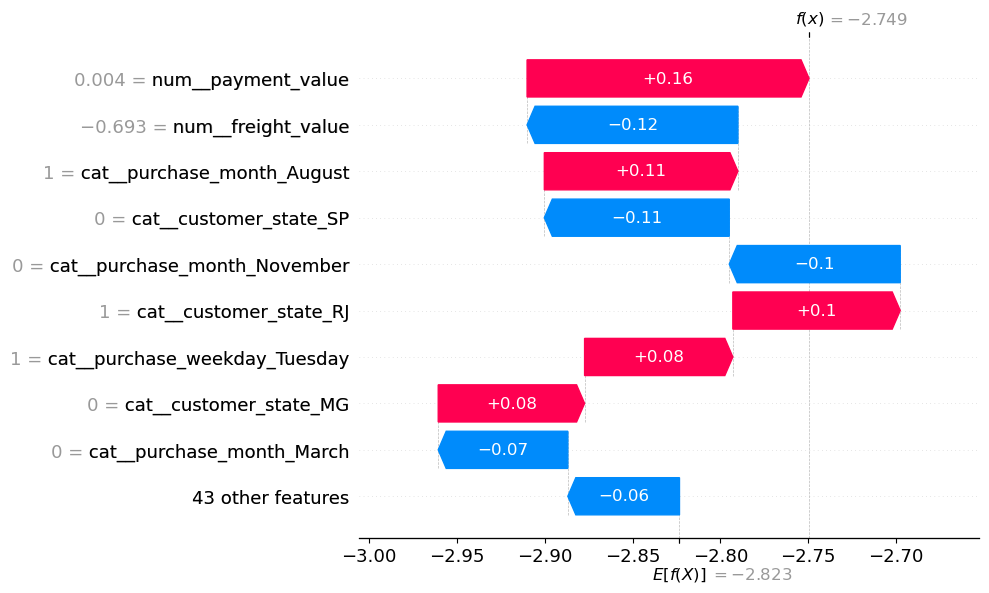

In [110]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[2],
        base_values=explainer.expected_value,
        data=X_test_dense[2],
        feature_names=feature_names
    )
)

## Individual Prediction Explanations

SHAP waterfall plots were used to explain individual model predictions.

Each plot shows how different features contributed positively or negatively to the final prediction.

Features pushing the prediction toward delayed delivery are shown in one direction, while features reducing delay risk are shown in the opposite direction.

This helps understand the specific factors responsible for each prediction and improves model transparency.